<a href="https://colab.research.google.com/github/atallamirna/Early-Detection-of-Type-2-Diabetes/blob/main/Diabetes_Early_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.metrics._plot.confusion_matrix import ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from numpy import std
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,precision_score, recall_score)

from google.colab import drive
drive.mount('/content/drive')

!pip install pygad
import pygad

# reading the pima and early dataset from google drive
pima = pd.read_csv("/content/drive/MyDrive/Diabetes/diabetes.csv")
pima.head()

early = pd.read_csv("/content/drive/MyDrive/Diabetes/Early_Diabetes.csv")
early.head()




Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.3/218.3 kB 12.4 MB/s eta 0:00:00


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [ ]:
# dealing with missing values (zero values replaced with the median)
cols_zero = ['Glucose','BloodPressure','BMI','Insulin','SkinThickness']

for col in cols_zero:
    pima[col] = pima[col].replace(0, pima[col].median())

#DV and IV pima data
X_pima = pima.drop('Outcome', axis=1)
y_pima = pima['Outcome']

#text to binary in early prediction data
le = LabelEncoder()
early['class'] = le.fit_transform(early['class'])

binary_columns = early.columns.drop(['Age', 'class'])
for col in binary_columns:
    early[col] = le.fit_transform(early[col])

#DV and IV early data
X_early = early.drop('class', axis=1)
y_early = early['class']


In [ ]:
#dividing the data to be trained (80/20)
Xp_train, Xp_test, yp_train, yp_test = train_test_split(X_pima, y_pima,
    test_size=0.2, stratify=y_pima, random_state=42)

Xe_train, Xe_test, ye_train, ye_test = train_test_split(X_early, y_early,
    test_size=0.2, stratify=y_early, random_state=42)

#scaling
scaler_pima = StandardScaler()
Xp_train = pd.DataFrame(scaler_pima.fit_transform(Xp_train), columns=X_pima.columns)
Xp_test  = pd.DataFrame(scaler_pima.transform(Xp_test), columns=X_pima.columns)

scaler_early = StandardScaler()
Xe_train = pd.DataFrame(scaler_early.fit_transform(Xe_train), columns=X_early.columns)
Xe_test  = pd.DataFrame(scaler_early.transform(Xe_test), columns=X_early.columns)


In [ ]:
#baseline model (logistic reg)
base_model = LogisticRegression(max_iter=1000)
base_model.fit(Xp_train, yp_train)
yp_pred = base_model.predict(Xp_test)

acc_pima_base = accuracy_score(yp_test, yp_pred)
f1_pima_base = f1_score(yp_test, yp_pred)
rec_pima_base = recall_score(yp_test, yp_pred)
prec_pima_base = precision_score(yp_test, yp_pred)

base_model.fit(Xe_train, ye_train)
ye_pred_base = base_model.predict(Xe_test)

acc_early_base = accuracy_score(ye_test, ye_pred_base)
prec_early_base = precision_score(ye_test, ye_pred_base)
rec_early_base = recall_score(ye_test, ye_pred_base)
f1_early_base = f1_score(ye_test, ye_pred_base)

print("BASELINE RESULTS")
print("Pima Baseline Accuracy:", acc_pima_base)
print("Pima Baseline F1-score:", f1_pima_base)
print("Pima Baseline Precision:", prec_pima_base)
print("Pima Baseline Recall:", rec_pima_base)
print("Early Baseline Accuracy:", acc_early_base)
print("Early Baseline F1-score:", f1_early_base)
print("Early Baseline Precision:", prec_early_base)
print("Early Baseline Recall:", rec_early_base)
print("-" * 50)



BASELINE RESULTS
Pima Baseline Accuracy: 0.7077922077922078
Pima Baseline F1-score: 0.5454545454545454
Pima Baseline Precision: 0.6
Pima Baseline Recall: 0.5
Early Baseline Accuracy: 0.9423076923076923
Early Baseline F1-score: 0.9516129032258065
Early Baseline Precision: 0.9833333333333333
Early Baseline Recall: 0.921875
--------------------------------------------------


In [ ]:
#greedy feature selection pima dataset
selected_pima = []
remaining_pima= list(Xp_train.columns)
best_score = 0

while remaining_pima:
    scores = []
    for f in remaining_pima:
        features = selected_pima + [f]
        score = cross_val_score(
            LogisticRegression(max_iter=1000),
            Xp_train[features],
            yp_train,
            cv=5,
            scoring='accuracy'
        ).mean()
        scores.append((f, score))

    best_feature, best_feature_score = max(scores, key=lambda x: x[1])

    if best_feature_score > best_score:
        selected_pima.append(best_feature)
        remaining_pima.remove(best_feature)
        best_score = best_feature_score
    else:
        break

#retrain after the greedy run
base_model.fit(Xp_train[selected_pima], yp_train)
yp_pred_greedy = base_model.predict(Xp_test[selected_pima])
acc_pima_greedy = accuracy_score(yp_test, yp_pred_greedy)
prec_pima_greedy = precision_score(yp_test, yp_pred_greedy)
rec_pima_greedy = recall_score(yp_test, yp_pred_greedy)
f1_pima_greedy = f1_score(yp_test, yp_pred_greedy)

print("GREEDY FEATURE SELECTION RESULTS")
print()
print("Pima Selected Features (Greedy):", selected_pima)
print("Number of Pima Greedy Features:", len(selected_pima))
print("Pima Greedy Accuracy:", acc_pima_greedy)
print("Pima Greedy Precision:", prec_pima_greedy)
print("Pima Greedy Recall:", rec_pima_greedy)
print("Pima Greedy F1-score:", f1_pima_greedy)
print()

#greedy feature selection early dataset
selected_early = []
remaining_early = list(Xe_train.columns)
best_score = 0

while remaining_early:
    scores = []
    for f in remaining_early:
        features = selected_early + [f]
        score = cross_val_score(
            LogisticRegression(max_iter=1000),
            Xe_train[features],
            ye_train,
            cv=5,
            scoring='accuracy'
        ).mean()
        scores.append((f, score))

    best_feature, best_feature_score = max(scores, key=lambda x: x[1])

    if best_feature_score > best_score:
        selected_early.append(best_feature)
        remaining_early.remove(best_feature)
        best_score = best_feature_score
    else:
        break

#retrain after the greedy run
base_model.fit(Xe_train[selected_early], ye_train)
ye_pred_greedy = base_model.predict(Xe_test[selected_early])
acc_early_greedy = accuracy_score(ye_test, ye_pred_greedy)
prec_early_greedy = precision_score(ye_test, ye_pred_greedy)
rec_early_greedy = recall_score(ye_test, ye_pred_greedy)
f1_early_greedy = f1_score(ye_test, ye_pred_greedy)

print("Early Selected Features (Greedy):", selected_early)
print("Number of Early Greedy Features:", len(selected_early))
print("Early Greedy Accuracy:", acc_early_greedy)
print("Early Greedy Precision:", prec_early_greedy)
print("Early Greedy Recall:", rec_early_greedy)
print("Early Greedy F1-score:", f1_early_greedy)
print("-" * 50)

GREEDY FEATURE SELECTION RESULTS

Pima Selected Features (Greedy): ['Glucose', 'BMI', 'Pregnancies', 'SkinThickness']
Number of Pima Greedy Features: 4
Pima Greedy Accuracy: 0.7012987012987013
Pima Greedy Precision: 0.5769230769230769
Pima Greedy Recall: 0.5555555555555556
Pima Greedy F1-score: 0.5660377358490566

Early Selected Features (Greedy): ['Polyuria', 'Gender', 'Polydipsia', 'Alopecia', 'delayed healing', 'Irritability']
Number of Early Greedy Features: 6
Early Greedy Accuracy: 0.9519230769230769
Early Greedy Precision: 0.9682539682539683
Early Greedy Recall: 0.953125
Early Greedy F1-score: 0.9606299212598425
--------------------------------------------------


In [ ]:
#genetic alg feature selection pima dataset
def fitness_pima(ga_instance, solution, solution_idx):
    selected = [
        Xp_train.columns[i]
        for i in range(len(solution))
        if solution[i] == 1
    ]

    if len(selected) == 0:
        return 0

    score = cross_val_score(
        LogisticRegression(max_iter=1000),
        Xp_train[selected],
        yp_train,
        cv=5,
        scoring='accuracy'
    ).mean()

    return score

#running the GA pima
ga_pima = pygad.GA(
    num_generations=30,
    num_parents_mating=10,
    fitness_func=fitness_pima,
    sol_per_pop=20,
    num_genes=Xp_train.shape[1],
    gene_space=[0,1],
    mutation_num_genes=1
)

ga_pima.run()

#extract features pima
solution_pima, fitness_pima, _ = ga_pima.best_solution()

ga_features_pima = [Xp_train.columns[i]
    for i in range(len(solution_pima))
    if solution_pima[i] == 1]


#Evaluate pima database
base_model.fit(Xp_train[ga_features_pima], yp_train)
yp_pred_ga = base_model.predict(Xp_test[ga_features_pima])
acc_pima_ga = accuracy_score(yp_test, yp_pred_ga)
prec_pima_ga = precision_score(yp_test, yp_pred_ga)
rec_pima_ga = recall_score(yp_test, yp_pred_ga)
f1_pima_ga = f1_score(yp_test, yp_pred_ga)

print("GENETIC ALGORITHM RESULTS - PIMA")
print("Selected Features (GA Pima):", ga_features_pima)
print("Number of GA Pima Features:", len(ga_features_pima))
print("GA Pima Accuracy:", acc_pima_ga)
print("GA Pima Precision:", prec_pima_ga)
print("GA Pima Recall:", rec_pima_ga)
print("GA Pima F1-score:", f1_pima_ga)

solution_pima, fitness_pima_value, _ = ga_pima.best_solution()
print("Best GA Fitness (Cross-validated Accuracy):", fitness_pima_value)
print("-" * 50)

# Genetic Algorithm fitness function for Early dataset
def fitness_early(ga_instance, solution, solution_idx):
    selected = [
        Xe_train.columns[i]
        for i in range(len(solution))
        if solution[i] == 1]

    if len(selected) == 0:
        return 0

    score = cross_val_score(
        LogisticRegression(max_iter=1000),
        Xe_train[selected],
        ye_train,
        cv=5,
        scoring='accuracy'
    ).mean()

    return score

#running the GA early dataset
ga_early = pygad.GA(
    num_generations=30,
    num_parents_mating=10,
    fitness_func=fitness_early,
    sol_per_pop=20,
    num_genes=Xe_train.shape[1],
    gene_space=[0,1],
    mutation_num_genes=1
)

ga_early.run()

#extract features early
solution_early, fitness_early_value, _ = ga_early.best_solution()

ga_features_early= [Xe_train.columns[i]
    for i in range(len(solution_early))
    if solution_early[i] == 1]

#Evaluate early database
base_model.fit(Xe_train[ga_features_early], ye_train)
ye_pred_ga = base_model.predict(Xe_test[ga_features_early])
acc_early_ga = accuracy_score(ye_test, ye_pred_ga)
prec_early_ga = precision_score(ye_test, ye_pred_ga)
rec_early_ga = recall_score(ye_test, ye_pred_ga)
f1_early_ga = f1_score(ye_test, ye_pred_ga)

print("GENETIC ALGORITHM RESULTS - EARLY")
print("Selected Features (GA Early):", ga_features_early)
print("Number of GA Early Features:", len(ga_features_early))
print("GA Early Accuracy:", acc_early_ga)
print("GA Early Precision:", prec_early_ga)
print("GA Early Recall:", rec_early_ga)
print("GA Early F1-score:", f1_early_ga)

solution_early, fitness_early_value, _ = ga_early.best_solution()
print("Best GA Fitness (Cross-validated Accuracy):", fitness_early_value)
print("-" * 50)



GENETIC ALGORITHM RESULTS - PIMA
Selected Features (GA Pima): ['Pregnancies', 'Glucose', 'SkinThickness', 'BMI']
Number of GA Pima Features: 4
GA Pima Accuracy: 0.7012987012987013
GA Pima Precision: 0.5769230769230769
GA Pima Recall: 0.5555555555555556
GA Pima F1-score: 0.5660377358490566
Best GA Fitness (Cross-validated Accuracy): 0.786711981873917
--------------------------------------------------
GENETIC ALGORITHM RESULTS - EARLY
Selected Features (GA Early): ['Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'partial paresis', 'muscle stiffness', 'Alopecia']
Number of GA Early Features: 11
GA Early Accuracy: 0.9326923076923077
GA Early Precision: 0.9830508474576272
GA Early Recall: 0.90625
GA Early F1-score: 0.943089430894309
Best GA Fitness (Cross-validated Accuracy): 0.9325874928284567
--------------------------------------------------


In [ ]:
# Mean +/- SD for all models
def cv_report(model, X, y, name):
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: mean={scores.mean():.4f}  std={scores.std():.4f}")
    return scores.mean(), scores.std()

results_cv = {}

# PIMA
results_cv['PIMA-Baseline'] = cv_report(
    LogisticRegression(max_iter=1000), Xp_train, yp_train, "PIMA Baseline")

results_cv['PIMA-Greedy'] = cv_report(
    LogisticRegression(max_iter=1000), Xp_train[selected_pima], yp_train, "PIMA Greedy")

results_cv['PIMA-GA'] = cv_report(
    LogisticRegression(max_iter=1000), Xp_train[ga_features_pima], yp_train, "PIMA GA")

results_cv['PIMA-RF'] = cv_report(
    RandomForestClassifier(n_estimators=200, random_state=42), Xp_train, yp_train, "PIMA RF")

print("-" * 50)

# EARLY
results_cv['EARLY-Baseline'] = cv_report(
    LogisticRegression(max_iter=1000), Xe_train, ye_train, "EARLY Baseline")

results_cv['EARLY-Greedy'] = cv_report(
    LogisticRegression(max_iter=1000), Xe_train[selected_early], ye_train, "EARLY Greedy")

results_cv['EARLY-GA'] = cv_report(
    LogisticRegression(max_iter=1000), Xe_train[ga_features_early], ye_train, "EARLY GA")

results_cv['EARLY-RF'] = cv_report(
    RandomForestClassifier(n_estimators=200, random_state=42), Xe_train, ye_train, "EARLY RF")

# Build a table
cv_table = pd.DataFrame([
    {"Dataset": k.split('-')[0], "Model": k.split('-')[1],
     "CV Mean Accuracy": v[0], "CV Std": v[1]}
    for k, v in results_cv.items()
])
print(cv_table)


PIMA Baseline: mean=0.7802  std=0.0180
PIMA Greedy: mean=0.7867  std=0.0265
PIMA GA: mean=0.7867  std=0.0265
PIMA RF: mean=0.7622  std=0.0258
--------------------------------------------------
EARLY Baseline: mean=0.9230  std=0.0330
EARLY Greedy: mean=0.9231  std=0.0124
EARLY GA: mean=0.9326  std=0.0386
EARLY RF: mean=0.9735  std=0.0141
  Dataset     Model  CV Mean Accuracy    CV Std
0    PIMA  Baseline          0.780181  0.018004
1    PIMA    Greedy          0.786712  0.026478
2    PIMA        GA          0.786712  0.026478
3    PIMA        RF          0.762228  0.025784
4   EARLY  Baseline          0.923006  0.032965
5   EARLY    Greedy          0.923064  0.012359
6   EARLY        GA          0.932587  0.038619
7   EARLY        RF          0.973494  0.014050


RANDOM FOREST RESULTS - PIMA
Accuracy: 0.7402597402597403
Precision: 0.64
Recall: 0.5925925925925926
F1-score: 0.6153846153846154

Top PIMA Features by RF:
Glucose                     0.268128
BMI                         0.160380
Age                         0.127067
DiabetesPedigreeFunction    0.123448
BloodPressure               0.089140
Pregnancies                 0.082398
Insulin                     0.075549
SkinThickness               0.073892
dtype: float64
--------------------------------------------------


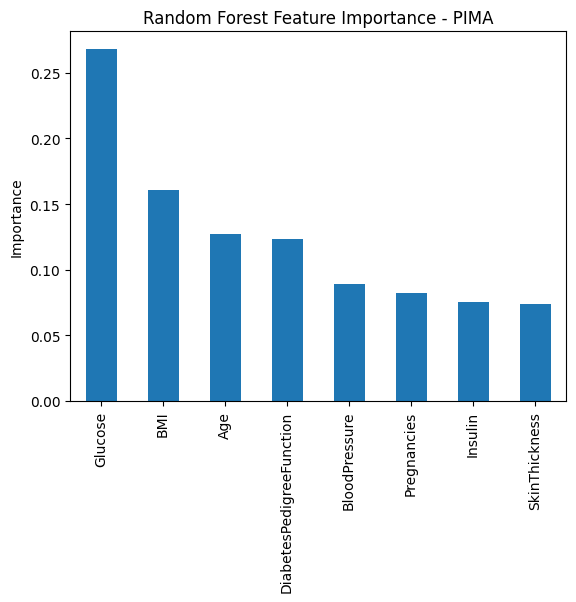

Random Forest PIMA CV Mean: 0.7622284419565508
Random Forest PIMA CV STD: 0.02578436270827297
--------------------------------------------------
Selected Top 4 PIMA Features: ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
RANDOM FOREST (Top Features Only) - PIMA
Accuracy: 0.7207792207792207
Precision: 0.6170212765957447
Recall: 0.5370370370370371
F1-score: 0.5742574257425742
--------------------------------------------------
RANDOM FOREST RESULTS - EARLY
Accuracy: 0.9807692307692307
Precision: 0.984375
Recall: 0.984375
F1-score: 0.984375

Top EARLY Features by RF:
Polyuria              0.193967
Polydipsia            0.183432
Gender                0.108216
Age                   0.107106
sudden weight loss    0.064087
partial paresis       0.049204
Alopecia              0.043173
Irritability          0.036921
Itching               0.033918
delayed healing       0.033536
Polyphagia            0.031324
visual blurring       0.028094
Genital thrush        0.024980
muscle stiffness   

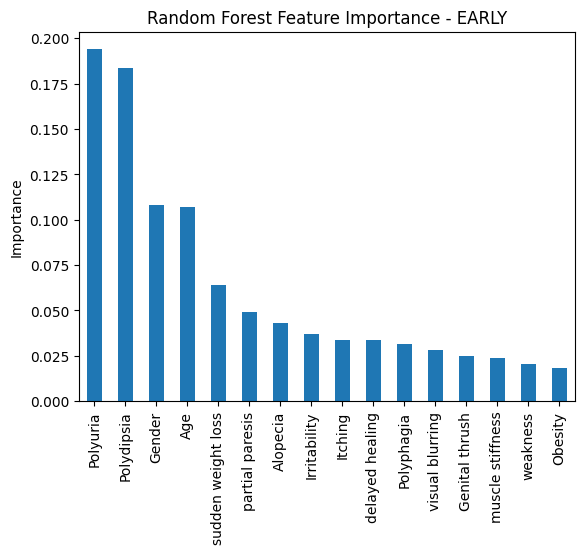

Random Forest EARLY CV Mean: 0.9734939759036145
Random Forest EARLY CV STD: 0.014050486493603137
--------------------------------------------------
Selected Top EARLY Features: ['Polyuria', 'Polydipsia', 'Gender', 'Age', 'sudden weight loss', 'partial paresis', 'Alopecia', 'Irritability']
RANDOM FOREST (Top Features Only) - Early
Accuracy: 0.9519230769230769
Precision: 0.9402985074626866
Recall: 0.984375
F1-score: 0.9618320610687023
--------------------------------------------------
MODEL COMPARISON - PIMA
Full Features RF Accuracy: 0.7402597402597403
Top Features RF Accuracy: 0.7207792207792207
--------------------------------------------------
MODEL COMPARISON - EARLY
Full Features RF Accuracy: 0.9807692307692307
Top Features RF Accuracy: 0.9519230769230769
--------------------------------------------------


In [ ]:
# RANDOM FOREST - PIMA
rf_pima = RandomForestClassifier(n_estimators=200,random_state=42)
rf_pima.fit(Xp_train, yp_train)

yp_pred_rf = rf_pima.predict(Xp_test)

acc_pima_rf = accuracy_score(yp_test, yp_pred_rf)
prec_pima_rf = precision_score(yp_test, yp_pred_rf)
rec_pima_rf = recall_score(yp_test, yp_pred_rf)
f1_pima_rf = f1_score(yp_test, yp_pred_rf)

print("RANDOM FOREST RESULTS - PIMA")
print("Accuracy:", acc_pima_rf)
print("Precision:", prec_pima_rf)
print("Recall:", rec_pima_rf)
print("F1-score:", f1_pima_rf)
print()

#  Feature importance
importances_pima = pd.Series(
    rf_pima.feature_importances_, index=Xp_train.columns
).sort_values(ascending=False)

print("Top PIMA Features by RF:")
print(importances_pima)
print("-"*50)

plt.figure()
importances_pima.plot(kind='bar')
plt.title("Random Forest Feature Importance - PIMA")
plt.ylabel("Importance")
plt.show()

rf_pima_cv = cross_val_score(
    rf_pima,
    Xp_train,
    yp_train,
    cv=5,
    scoring='accuracy'
)

print("Random Forest PIMA CV Mean:", rf_pima_cv.mean())
print("Random Forest PIMA CV STD:", rf_pima_cv.std())
print("-"*50)

# RANDOM FOREST WITH TOP FEATURES ONLY (PIMA)

top_features_pima = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
print("Selected Top 4 PIMA Features:", top_features_pima)

Xp_train_top = Xp_train[top_features_pima]
Xp_test_top = Xp_test[top_features_pima]

rf_pima_top = RandomForestClassifier(n_estimators=200, random_state=42)
rf_pima_top.fit(Xp_train_top, yp_train)

yp_pred_top = rf_pima_top.predict(Xp_test_top)

acc_top_pima = accuracy_score(yp_test, yp_pred_top)
prec_top_pima = precision_score(yp_test, yp_pred_top)
rec_top_pima = recall_score(yp_test, yp_pred_top)
f1_top_pima = f1_score(yp_test, yp_pred_top)

print("RANDOM FOREST (Top Features Only) - PIMA")
print("Accuracy:", acc_top_pima)
print("Precision:", prec_top_pima)
print("Recall:", rec_top_pima)
print("F1-score:", f1_top_pima)
print("-"*50)

# RANDOM FOREST - EARLY
rf_early = RandomForestClassifier(n_estimators=200, random_state=42)
rf_early.fit(Xe_train, ye_train)

ye_pred_rf = rf_early.predict(Xe_test)

acc_early_rf = accuracy_score(ye_test, ye_pred_rf)
prec_early_rf = precision_score(ye_test, ye_pred_rf)
rec_early_rf = recall_score(ye_test, ye_pred_rf)
f1_early_rf = f1_score(ye_test, ye_pred_rf)

print("RANDOM FOREST RESULTS - EARLY")
print("Accuracy:", acc_early_rf)
print("Precision:", prec_early_rf)
print("Recall:", rec_early_rf)
print("F1-score:", f1_early_rf)
print()

# Feature Importance
importances_early = pd.Series(rf_early.feature_importances_,
    index=Xe_train.columns
).sort_values(ascending=False)

print("Top EARLY Features by RF:")
print(importances_early)
print("-"*50)

plt.figure()
importances_early.plot(kind='bar')
plt.title("Random Forest Feature Importance - EARLY")
plt.ylabel("Importance")
plt.show()

rf_early_cv = cross_val_score(
    rf_early,
    Xe_train,
    ye_train,
    cv=5,
    scoring='accuracy'
)

print("Random Forest EARLY CV Mean:", rf_early_cv.mean())
print("Random Forest EARLY CV STD:", rf_early_cv.std())
print("-"*50)

# RANDOM FOREST WITH TOP FEATURES ONLY (Early)

top_features_early = ['Polyuria', 'Polydipsia', 'Gender', 'Age', 'sudden weight loss',
                      'partial paresis', 'Alopecia', 'Irritability']
print("Selected Top EARLY Features:", top_features_early)

Xe_train_top = Xe_train[top_features_early]
Xe_test_top = Xe_test[top_features_early]

rf_early_top = RandomForestClassifier(n_estimators=200, random_state=42)
rf_early_top.fit(Xe_train_top, ye_train)

ye_pred_top = rf_early_top.predict(Xe_test_top)

acc_top_early = accuracy_score(ye_test, ye_pred_top)
prec_top_early = precision_score(ye_test, ye_pred_top)
rec_top_early = recall_score(ye_test, ye_pred_top)
f1_top_early = f1_score(ye_test, ye_pred_top)

print("RANDOM FOREST (Top Features Only) - Early")
print("Accuracy:", acc_top_early)
print("Precision:", prec_top_early)
print("Recall:", rec_top_early)
print("F1-score:", f1_top_early)
print("-"*50)


print("MODEL COMPARISON - PIMA")
print("Full Features RF Accuracy:", acc_pima_rf)
print("Top Features RF Accuracy:", acc_top_pima)
print("-"*50)

print("MODEL COMPARISON - EARLY")
print("Full Features RF Accuracy:", acc_early_rf)
print("Top Features RF Accuracy:", acc_top_early)
print("-"*50)

In [ ]:
#statistical stability
rf_pima_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42),
    Xp_train,
    yp_train,
    cv=5,
    scoring='accuracy'
)

rf_early_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42),
    Xe_train,
    ye_train,
    cv=5,
    scoring='accuracy'
)

print("STATISTICAL STABILITY - RANDOM FOREST")
print("PIMA RF Accuracy STD:", np.std(rf_pima_cv_scores))
print("EARLY RF Accuracy STD:", np.std(rf_early_cv_scores))
print("-"*50)

STATISTICAL STABILITY - RANDOM FOREST
PIMA RF Accuracy STD: 0.02578436270827297
EARLY RF Accuracy STD: 0.014050486493603137
--------------------------------------------------


In [ ]:
#printing all results for comparison
print("PIMA RESULTS")
print("Baseline:")
print("Acc:", acc_pima_base)
print("Prec:", prec_pima_base)
print("Rec:", rec_pima_base)
print("F1:", f1_pima_base)
print()

print("Greedy:")
print("Acc:", acc_pima_greedy)
print("Prec:", prec_pima_greedy)
print("Rec:", rec_pima_greedy)
print("F1:", f1_pima_greedy)
print("Features:", len(selected_pima))
print ()

print("GA:")
print("Acc:", acc_pima_ga)
print("Prec:", prec_pima_ga)
print("Rec:", rec_pima_ga)
print("F1:", f1_pima_ga)
print("Features:", len(ga_features_pima))
print()

print("Random Forest:")
print("Acc:", acc_pima_rf)
print("prec:", prec_pima_rf)
print("rec:", rec_pima_rf)
print("f1:", f1_pima_rf)
print()

print("Selected (Greedy):", selected_pima)
print("Selected (GA):", ga_features_pima)
print("-"*50)


print("EARLY RESULTS")
print("Baseline:")
print("Acc:", acc_early_base)
print("Prec:", prec_early_base)
print("Rec:", rec_early_base)
print("F1:", f1_early_base)
print()

print("Greedy:")
print("Acc:", acc_early_greedy)
print("Prec:", prec_early_greedy)
print("Rec:", rec_early_greedy)
print("F1:", f1_early_greedy)
print("Features:", len(selected_early))
print()

print("GA:")
print("Acc:", acc_early_ga)
print("Prec:", prec_early_ga)
print("Rec:", rec_early_ga)
print("F1:", f1_early_ga)
print("Features:", len(ga_features_early))
print()

print("Random Forest:")
print("Acc:", acc_early_rf)
print("prec:", prec_early_rf)
print("rec:", rec_early_rf)
print("f1:", f1_early_rf)
print()

print("Selected (Greedy):", selected_early)
print("Selected (GA):", ga_features_early)
print()

print("STATISTICAL STABILITY - RANDOM FOREST")
print("PIMA RF Accuracy STD:", np.std(rf_pima_cv_scores))
print("EARLY RF Accuracy STD:", np.std(rf_early_cv_scores))
print("-"*50)




PIMA RESULTS
Baseline:
Acc: 0.7077922077922078
Prec: 0.6
Rec: 0.5
F1: 0.5454545454545454

Greedy:
Acc: 0.7012987012987013
Prec: 0.5769230769230769
Rec: 0.5555555555555556
F1: 0.5660377358490566
Features: 4

GA:
Acc: 0.7012987012987013
Prec: 0.5769230769230769
Rec: 0.5555555555555556
F1: 0.5660377358490566
Features: 4

Random Forest:
Acc: 0.7402597402597403
prec: 0.64
rec: 0.5925925925925926
f1: 0.6153846153846154

Selected (Greedy): ['Glucose', 'BMI', 'Pregnancies', 'SkinThickness']
Selected (GA): ['Pregnancies', 'Glucose', 'SkinThickness', 'BMI']
--------------------------------------------------
EARLY RESULTS
Baseline:
Acc: 0.9423076923076923
Prec: 0.9833333333333333
Rec: 0.921875
F1: 0.9516129032258065

Greedy:
Acc: 0.9519230769230769
Prec: 0.9682539682539683
Rec: 0.953125
F1: 0.9606299212598425
Features: 6

GA:
Acc: 0.9326923076923077
Prec: 0.9830508474576272
Rec: 0.90625
F1: 0.943089430894309
Features: 11

Random Forest:
Acc: 0.9807692307692307
prec: 0.984375
rec: 0.984375
f1: 0.9

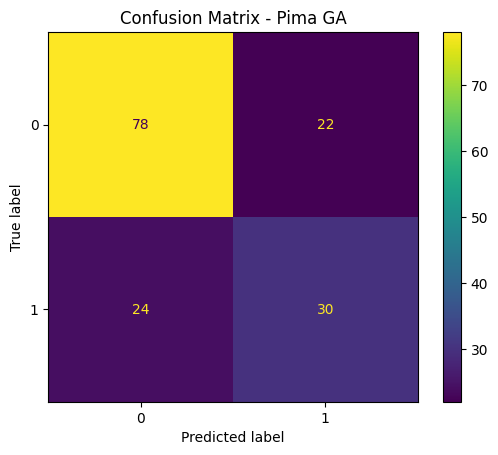

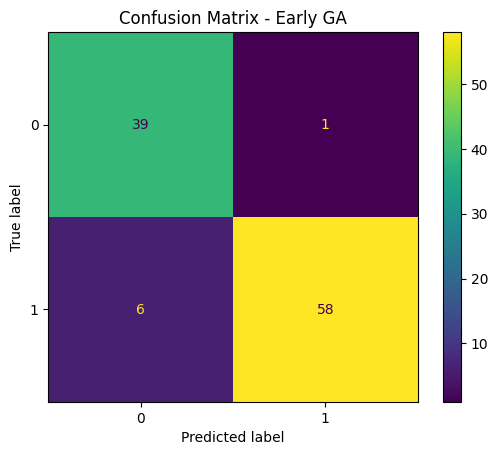

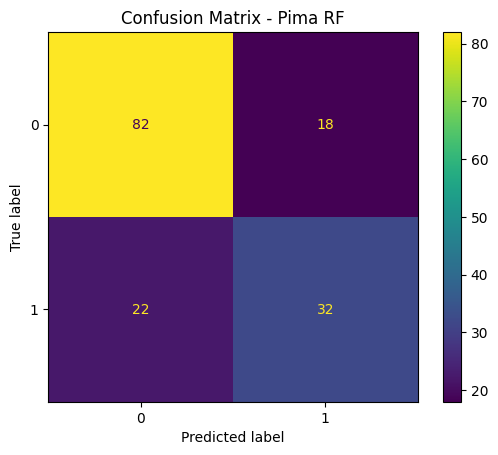

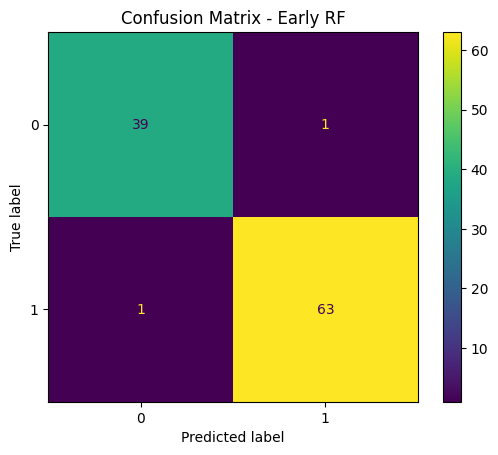

In [ ]:
#confusion matrix
ConfusionMatrixDisplay.from_predictions(yp_test, yp_pred_ga)
plt.title("Confusion Matrix - Pima GA")
plt.show()

ConfusionMatrixDisplay.from_predictions(ye_test, ye_pred_ga)
plt.title("Confusion Matrix - Early GA")
plt.show()

ConfusionMatrixDisplay.from_predictions(yp_test, yp_pred_rf)
plt.title("Confusion Matrix - Pima RF")
plt.show()

ConfusionMatrixDisplay.from_predictions(ye_test, ye_pred_rf)
plt.title("Confusion Matrix - Early RF")
plt.show()


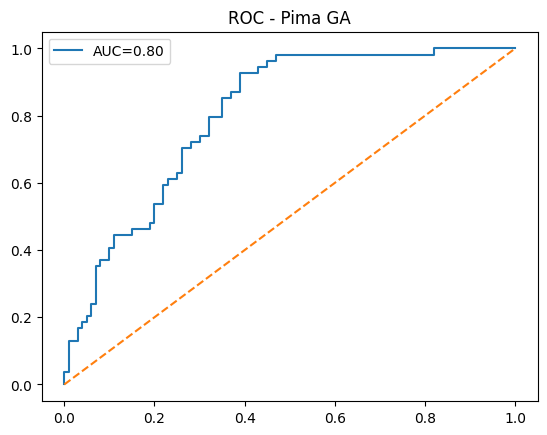

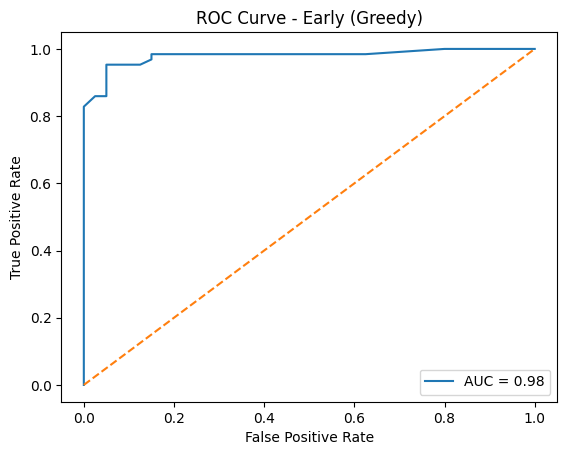

AUC: 0.9792968750000001


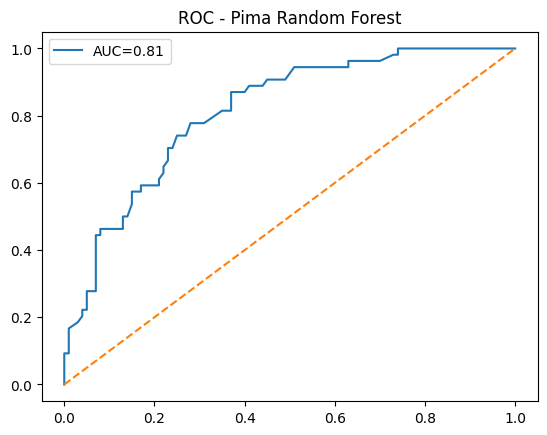

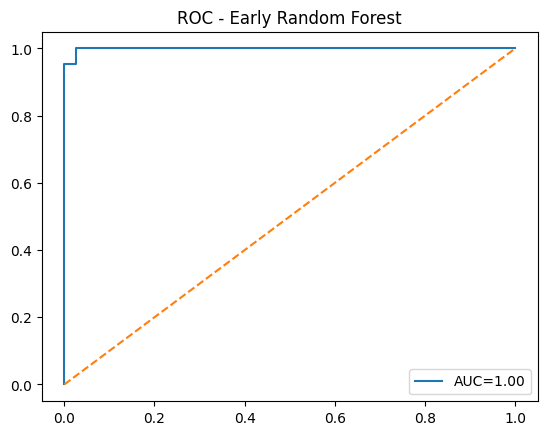

In [ ]:
#ROC curve
base_model = LogisticRegression(max_iter=1000)
base_model.fit(Xp_train[ga_features_pima], yp_train)
yp_prob = base_model.predict_proba(Xp_test[ga_features_pima])[:,1]
fpr, tpr, _ = roc_curve(yp_test, yp_prob)
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC - Pima GA")
plt.legend()
plt.show()


base_model = LogisticRegression(max_iter=1000)
base_model.fit(Xe_train[selected_early], ye_train)
ye_prob = base_model.predict_proba(Xe_test[selected_early])[:, 1]
fpr, tpr, thresholds = roc_curve(ye_test, ye_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Early (Greedy)")
plt.legend()
plt.show()

print("AUC:", roc_auc)

yp_prob_rf = rf_pima.predict_proba(Xp_test)[:,1]
auc_pima_rf = auc(*roc_curve(yp_test, yp_prob_rf)[:2])
fpr, tpr, _ = roc_curve(yp_test, yp_prob_rf)
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC - Pima Random Forest")
plt.legend()
plt.show()

ye_prob_rf = rf_early.predict_proba(Xe_test)[:,1]
auc_early_rf = auc(*roc_curve(ye_test, ye_prob_rf)[:2])
fpr, tpr, _ = roc_curve(ye_test, ye_prob_rf)
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC - Early Random Forest")
plt.legend()
plt.show()



In [ ]:
#comparison matrix
comparison_df = pd.DataFrame({
    "Dataset": [
        "PIMA","PIMA","PIMA","PIMA",
        "EARLY","EARLY","EARLY","EARLY"
    ],
    "Model": [
        "Baseline","Greedy","GA","RandomForest",
        "Baseline","Greedy","GA","RandomForest"
    ],
    "Accuracy": [
        acc_pima_base, acc_pima_greedy, acc_pima_ga, acc_pima_rf,
        acc_early_base, acc_early_greedy, acc_early_ga, acc_early_rf
    ],
    "F1-score": [
        f1_pima_base, f1_pima_greedy, f1_pima_ga, f1_pima_rf,
        f1_early_base, f1_early_greedy, f1_early_ga, f1_early_rf
    ]
})

print(comparison_df)


  Dataset         Model  Accuracy  F1-score
0    PIMA      Baseline  0.707792  0.545455
1    PIMA        Greedy  0.701299  0.566038
2    PIMA            GA  0.701299  0.566038
3    PIMA  RandomForest  0.740260  0.615385
4   EARLY      Baseline  0.942308  0.951613
5   EARLY        Greedy  0.951923  0.960630
6   EARLY            GA  0.932692  0.943089
7   EARLY  RandomForest  0.980769  0.984375


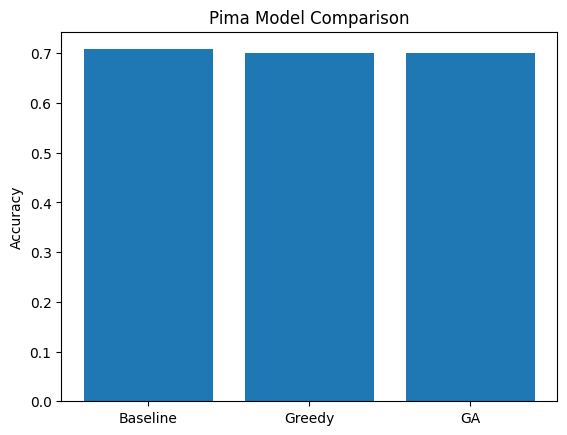

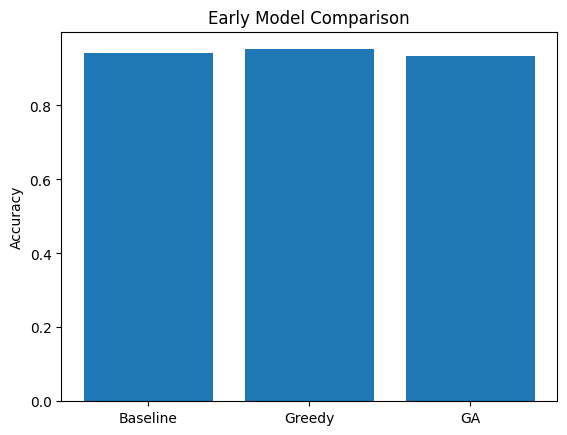

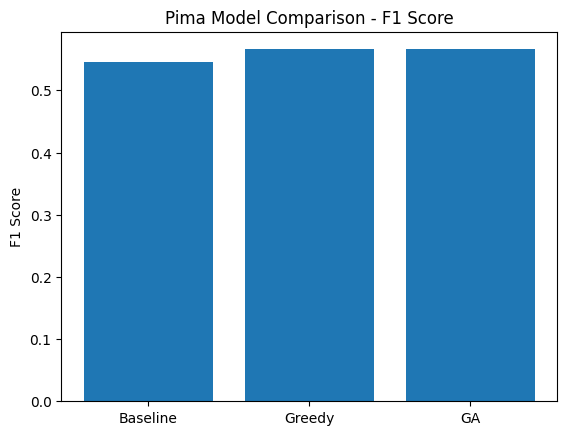

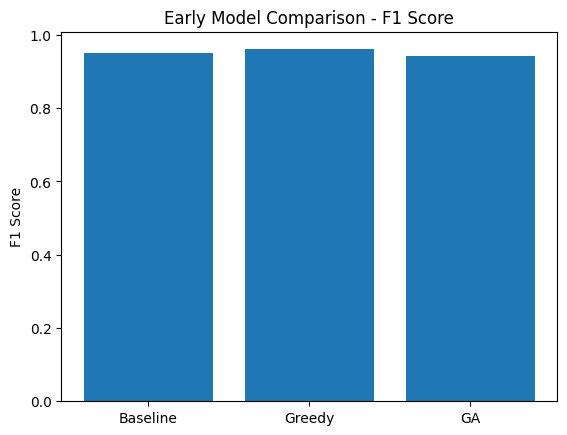

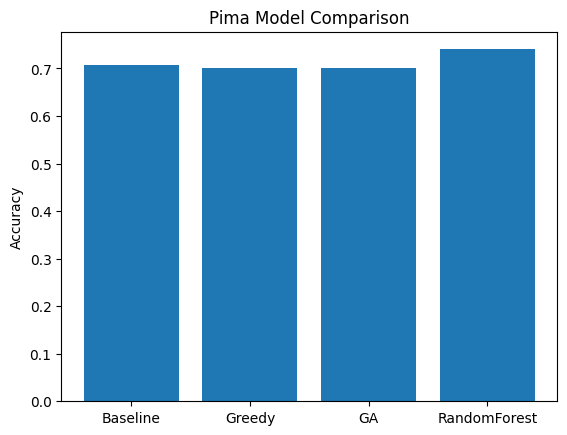

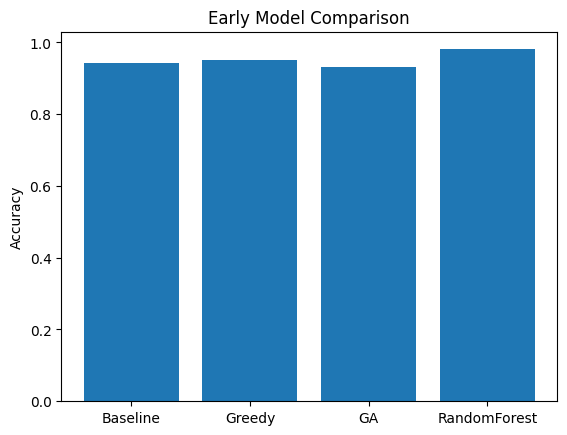

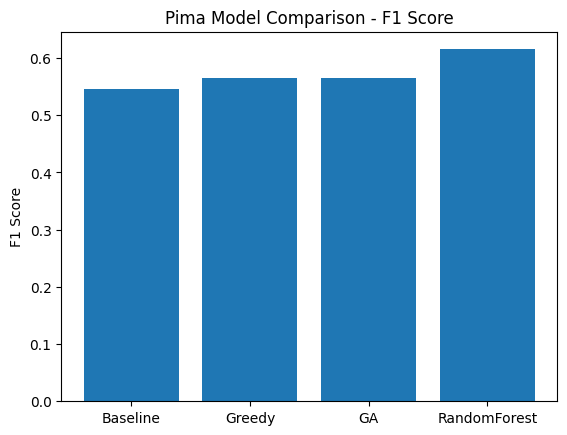

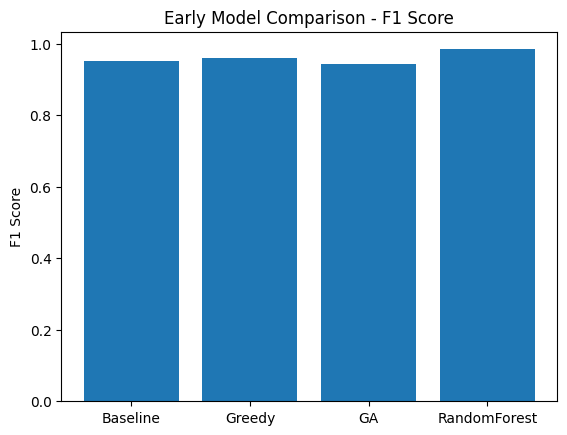

In [ ]:
#accuracy comparison - Greedy and GA
models = ['Baseline','Greedy','GA']

pima_scores = [acc_pima_base, acc_pima_greedy, acc_pima_ga]

plt.bar(models, pima_scores)
plt.title("Pima Model Comparison")
plt.ylabel("Accuracy")
plt.show()
early_scores = [acc_early_base, acc_early_greedy, acc_early_ga]

plt.bar(models, early_scores)
plt.title("Early Model Comparison")
plt.ylabel("Accuracy")
plt.show()

pima_f1_scores = [f1_pima_base, f1_pima_greedy, f1_pima_ga]

plt.bar(models, pima_f1_scores)
plt.title("Pima Model Comparison - F1 Score")
plt.ylabel("F1 Score")
plt.show()

early_f1_scores = [f1_early_base, f1_early_greedy, f1_early_ga]

plt.bar(models, early_f1_scores)
plt.title("Early Model Comparison - F1 Score")
plt.ylabel("F1 Score")
plt.show()

#accuracy comparison - all
models_all = ['Baseline','Greedy','GA','RandomForest']

pima_scores_all = [acc_pima_base, acc_pima_greedy, acc_pima_ga, acc_pima_rf]

plt.bar(models_all, pima_scores_all)
plt.title("Pima Model Comparison")
plt.ylabel("Accuracy")
plt.show()

early_scores_all = [acc_early_base, acc_early_greedy, acc_early_ga, acc_early_rf]

plt.bar(models_all, early_scores_all)
plt.title("Early Model Comparison")
plt.ylabel("Accuracy")
plt.show()

pima_f1_scores_all = [f1_pima_base, f1_pima_greedy, f1_pima_ga, f1_pima_rf]

plt.bar(models_all, pima_f1_scores_all)
plt.title("Pima Model Comparison - F1 Score")
plt.ylabel("F1 Score")
plt.show()

early_f1_scores_all = [f1_early_base, f1_early_greedy, f1_early_ga, f1_early_rf]

plt.bar(models_all, early_f1_scores_all)
plt.title("Early Model Comparison - F1 Score")
plt.ylabel("F1 Score")
plt.show()
